This code assumes you have OligoAI cloned in the same directory. 
If you have Blackwell architechture, this fork fixes the code
https://github.com/RedPenguin100/OligoAI

In [1]:
!uv pip install ml-collections==0.1.1

Using Python 3.11.15 environment at: /home/michael/anaconda3/envs/oligo_5090_hybrid
Checked 1 package in 1ms


In [2]:
!uv pip install matplotlib

Using Python 3.11.15 environment at: /home/michael/anaconda3/envs/oligo_5090_hybrid
Checked 1 package in 1ms


In [3]:
!uv pip install seaborn

Using Python 3.11.15 environment at: /home/michael/anaconda3/envs/oligo_5090_hybrid
Checked 1 package in 1ms


In [4]:
import sys
import os
import pandas as pd

# ==========================================
# CELL 1: Setup & Configuration
# ==========================================

# Define the folder where you cloned the repository.
# You can easily change this string if you move the folder later.
REPO_DIR = "OligoAI"

# Dynamically add the subfolder to the Python path so imports work correctly
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

# Now we can safely import the inference function from the subfolder
try:
    from run_inference import run_inference
except ImportError as e:
    print(f"Import Error: {e}. Please ensure '{REPO_DIR}' contains run_inference.py")

Loading model and starting inference...
Using device: cuda

Dataset split distribution:
split
test    18153
Name: count, dtype: int64
Loading model from: OligoAI/OligoAI_11_09_25.ckpt


/home/michael/anaconda3/envs/oligo_5090_hybrid/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'scaler' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['scaler'])`.


Model loaded successfully with saved scaler: <class 'rinalmo.utils.scaler.StandardScaler'>
Using Transfection Method Vocabulary: {'Electroporation': 0, 'Gymnosis': 1, 'Other': 2, 'Lipofection': 3}
Using Chemistry Vocabulary: {'<pad>': 0, 'DNA': 1, 'MOE': 2, 'cET': 3}
Using Backbone Vocabulary: {'<pad>': 0, 'PO': 1, 'PS': 2}
Loaded dataset with 18153 samples

Starting inference...
Processed 2560 samples...
Processed 5120 samples...
Processed 7680 samples...
Processed 10240 samples...
Processed 12800 samples...
Processed 15360 samples...
Processed 17920 samples...
Inference completed. Generated 18153 predictions

Overall Prediction Statistics:
MAE: 21.1670
RMSE: 27.2778
R²: 0.1635
Pearson correlation: 0.4044
Spearman correlation: 0.4038

Per-split Statistics:
------------------------------------------------------------
TEST  - Samples:  18153
        MAE: 21.1670, RMSE: 27.2778
        R²: 0.1635, Pearson: 0.4044, Spearman: 0.4038
---------------------------------------------------------

,custom_id,Canonical Gene Name,Cell_line,inhibition_percent,predicted_inhibition_percent
0,IRF5_KARPAS-229,IRF5,KARPAS-229,38.0,58.278244
1,SOD1_HepG2,SOD1,HepG2,6.0,55.106300
2,SOD1_HepG2,SOD1,HepG2,12.0,55.160404
3,SOD1_HepG2,SOD1,HepG2,51.0,54.774902
4,SOD1_HepG2,SOD1,HepG2,52.0,54.659927



>>> Median Spearman Correlation (Gene x Cell Line): 0.3979 <<<


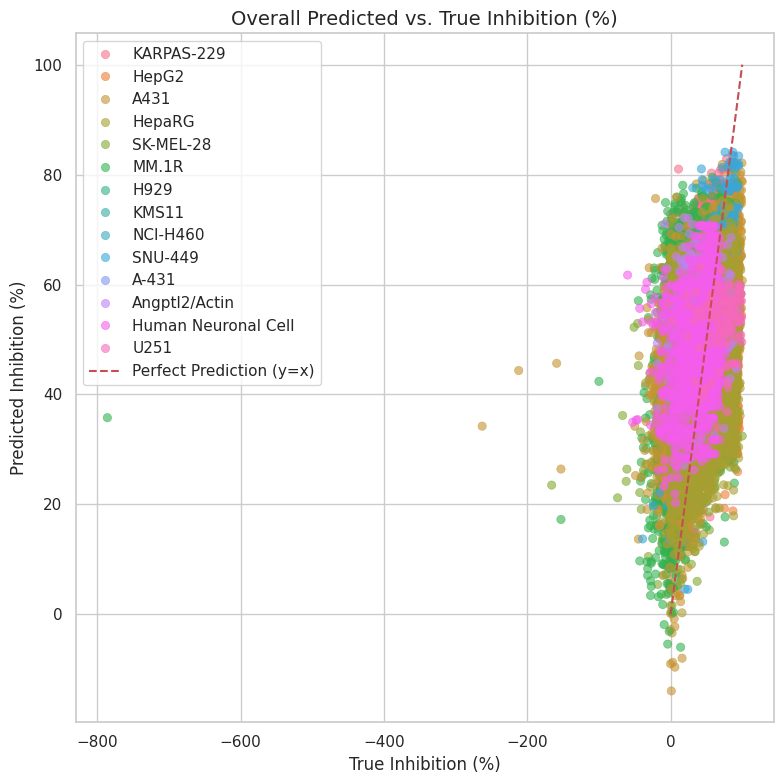

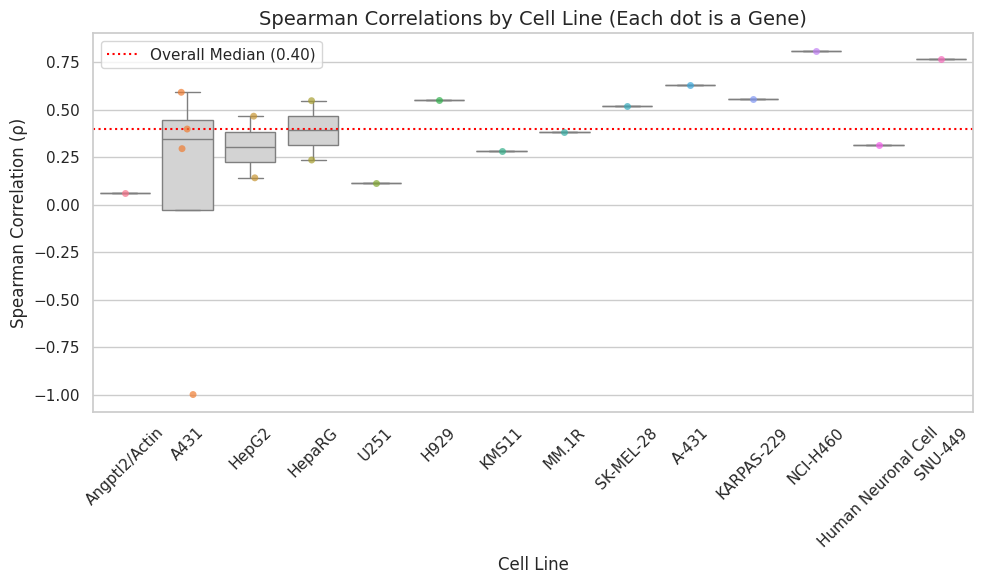

In [5]:
# ==========================================
# CELL 3: Execution, Evaluation & Plotting
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
import numpy as np

model_weights = os.path.join(REPO_DIR, 'OligoAI_11_09_25.ckpt')

print("Loading model and starting inference...")

CELL_LINE = 'Cell_line'
CANONICAL_GENE = 'Canonical Gene Name'

# Run the inference
results_df = run_inference(
    model_checkpoint_path=model_weights,
    data_path='asoptimizer_adapted.csv',
    batch_size=256,
    device='cuda'
)

print("\n--- Final Predicted Efficacies ---")
display(results_df[['custom_id', CANONICAL_GENE, CELL_LINE, 'inhibition_percent', 'predicted_inhibition_percent']].head())

# ==========================================
# EVALUATION: Median Spearman (Gene x Cell Line)
# ==========================================

# Drop any rows missing predictions or true values
eval_df = results_df.dropna(subset=['inhibition_percent', 'predicted_inhibition_percent'])

def calculate_spearman(group):
    # Spearman requires at least 2 data points with variance
    if len(group) > 1:
        corr, p_value = spearmanr(group['inhibition_percent'], group['predicted_inhibition_percent'])
        return corr
    return np.nan

# Group and calculate
grouped_corrs = eval_df.groupby([CANONICAL_GENE, CELL_LINE]).apply(calculate_spearman).reset_index(name='spearman_corr')

# Drop groups that couldn't be calculated (NaNs)
grouped_corrs = grouped_corrs.dropna(subset=['spearman_corr'])

median_spearman = grouped_corrs['spearman_corr'].median()
print(f"\n>>> Median Spearman Correlation (Gene x Cell Line): {median_spearman:.4f} <<<")


In [6]:
# ==========================================
# CELL 4: Subset Evaluation by Modification Type
# ==========================================

# 1. Define the exact modification strings you want to isolate
target_mods = [
    'cEt/5-methylcytosines/deoxy', 
    'MOE/5-methylcytosines/deoxy', 
    'LNA/deoxy'
]

print("--- Median Spearman Correlation by Modification Type ---\n")

# 2. Iterate through each modification type individually
for mod in target_mods:
    # Filter results for just this specific modification
    mod_df = results_df[results_df['Modification'] == mod].copy()
    
    # Drop rows missing predictions or true values
    eval_mod_df = mod_df.dropna(subset=['inhibition_percent', 'predicted_inhibition_percent'])
    
    subset_size = len(eval_mod_df)
    
    # Check if we have any data before proceeding
    if subset_size == 0:
        print(f"[{mod}] (N=0 rows)")
        print(f"    -> Cannot calculate: No data found for this modification.\n")
        continue
        
    # 3. Group and calculate Spearman (re-using your calculate_spearman function)
    grouped_corrs = eval_mod_df.groupby(
        [CANONICAL_GENE, CELL_LINE]
    ).apply(calculate_spearman).reset_index(name='spearman_corr')
    
    # Drop groups that couldn't be calculated (e.g., < 2 items or no variance)
    grouped_corrs = grouped_corrs.dropna(subset=['spearman_corr'])
    
    # 4. Calculate and report the final median for this mod
    if not grouped_corrs.empty:
        median_val = grouped_corrs['spearman_corr'].median()
        num_groups = len(grouped_corrs)
        print(f"[{mod}] (N={subset_size} rows)")
        print(f"    -> Median Spearman: {median_val:.4f} (Calculated across {num_groups} Gene/Cell Line groups)\n")
    else:
        print(f"[{mod}] (N={subset_size} rows)")
        print(f"    -> Cannot calculate Spearman: Not enough variance within the individual groups.\n")

--- Median Spearman Correlation by Modification Type ---

[cEt/5-methylcytosines/deoxy] (N=12615 rows)
    -> Median Spearman: 0.5354 (Calculated across 12 Gene/Cell Line groups)

[MOE/5-methylcytosines/deoxy] (N=3046 rows)
    -> Median Spearman: 0.1409 (Calculated across 5 Gene/Cell Line groups)

[LNA/deoxy] (N=2256 rows)
    -> Median Spearman: 0.1141 (Calculated across 3 Gene/Cell Line groups)



In [7]:
final_data = results_df


In [8]:
final_data = final_data[final_data['Cell_line'] != 'LLC-MK2 monkey']
final_data = final_data[final_data['Canonical Gene Name'] != 'HBV']


In [9]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

# (Assuming final_data already has 'predicted_inhibition_percent' added)

# 1. Define a helper function to calculate metrics including sample size and modification prevalence
def get_cohort_metrics(group):
    n_samples = len(group)
    
    # Calculate most common modification and its prevalence
    # value_counts(normalize=True) returns the fraction (0 to 1) of each unique value
    if 'Modification' in group.columns and n_samples > 0:
        mod_counts = group['Modification'].value_counts(normalize=True)
        most_common_mod = mod_counts.index[0] if not mod_counts.empty else np.nan
        mod_prevalence = mod_counts.iloc[0] if not mod_counts.empty else np.nan
    else:
        most_common_mod = np.nan
        mod_prevalence = np.nan

    # Spearman correlation requires at least 2 data points.
    if n_samples > 1:
        corr, p_val = spearmanr(group['inhibition_percent'], group['predicted_inhibition_percent'])
        return pd.Series({
            'spearman_correlation': corr,
            'n_samples': n_samples,
            'p_value': p_val,
            'most_common_mod': most_common_mod,
            'mod_prevalence': mod_prevalence
        })
    else:
        return pd.Series({
            'spearman_correlation': np.nan,
            'n_samples': n_samples,
            'p_value': np.nan,
            'most_common_mod': most_common_mod,
            'mod_prevalence': mod_prevalence
        })

# 2. Group by the cross product of Cell_line and Canonical Gene Name
cohort_metrics = (
    final_data.groupby(['Cell_line', 'Canonical Gene Name'])
    .apply(get_cohort_metrics)
    .reset_index()
)

# 3. Filter out any NaNs (cohorts with <2 samples or zero variance)
valid_cohorts = cohort_metrics.dropna(subset=['spearman_correlation']).copy()

# Sort the dataset so the printouts are in order
valid_cohorts = valid_cohorts.sort_values(by='spearman_correlation', ascending=False)


# 4. Helper function to calculate and print summary metrics for a given subset
def print_summary_metrics(df, title):
    if len(df) == 0:
        print(f"--- {title} ---")
        print("No valid cohorts in this subset.\n")
        return
        
    median_spearman = df['spearman_correlation'].median()
    mean_spearman = df['spearman_correlation'].mean()
    weighted_mean_spearman = np.average(df['spearman_correlation'], weights=df['n_samples'])
    
    print(f"--- {title} ---")
    print(f"Total Valid Cohorts: {len(df)}")
    print(f"Median Spearman Correlation: {median_spearman:.4f}")
    print(f"Simple Mean Spearman Correlation: {mean_spearman:.4f}")
    print(f"Sample-Size Weighted Mean Correlation: {weighted_mean_spearman:.4f}\n")


# 5. Output Results for ALL Cohorts
print_summary_metrics(valid_cohorts, "ALL COHORTS")

# 6. Output Results for Cohorts strictly > 50 samples
large_cohorts = valid_cohorts[valid_cohorts['n_samples'] > 50]
print_summary_metrics(large_cohorts, "COHORTS > 50 SAMPLES")


# 7. Print Individual Cohort Details
print("--- Individual Cohort Metrics ---")
# Format the prevalence as a readable percentage (e.g., 0.85 -> "85.0%") for the final display
display_df = valid_cohorts.copy()
display_df['mod_prevalence'] = (display_df['mod_prevalence'] * 100).map('{:.1f}%'.format)

print(display_df.to_string(index=False))

--- ALL COHORTS ---
Total Valid Cohorts: 19
Median Spearman Correlation: 0.3979
Simple Mean Spearman Correlation: 0.3504
Sample-Size Weighted Mean Correlation: 0.3414

--- COHORTS > 50 SAMPLES ---
Total Valid Cohorts: 14
Median Spearman Correlation: 0.3891
Simple Mean Spearman Correlation: 0.3845
Sample-Size Weighted Mean Correlation: 0.3407

--- Individual Cohort Metrics ---
          Cell_line Canonical Gene Name  spearman_correlation  n_samples       p_value             most_common_mod mod_prevalence
           NCI-H460                KRAS              0.811189         12  1.363315e-03 cEt/5-methylcytosines/deoxy          91.7%
            SNU-449                YAP1              0.768185        181  1.665798e-36 cEt/5-methylcytosines/deoxy         100.0%
              A-431                IRF5              0.631698         36  3.599145e-05 cEt/5-methylcytosines/deoxy         100.0%
               A431                KRAS              0.591288        489  1.952320e-47 cEt/5-methylcy

In [10]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

# (Assuming final_data already has 'predicted_inhibition_percent' added)

# 1. Helper function for calculating correlation on a pure subset
def get_pure_cohort_metrics(group):
    n_samples = len(group)
    if n_samples > 1:
        # Prevent spearmanr from throwing errors if a subset has zero variance
        if group['inhibition_percent'].nunique() > 1 and group['predicted_inhibition_percent'].nunique() > 1:
            corr, p_val = spearmanr(group['inhibition_percent'], group['predicted_inhibition_percent'])
        else:
            corr, p_val = np.nan, np.nan

        return pd.Series({
            'spearman_correlation': corr,
            'n_samples': n_samples,
            'p_value': p_val
        })
    else:
        return pd.Series({
            'spearman_correlation': np.nan,
            'n_samples': n_samples,
            'p_value': np.nan
        })

# 2. THE CRUCIAL CHANGE: Group by Modification AND the Cohort identifiers.
# This forces mixed cohorts (like A431/KRAS) to split into pure sub-groups.
pure_cohort_metrics = (
    final_data.groupby(['Modification', 'Cell_line', 'Canonical Gene Name'])
    .apply(get_pure_cohort_metrics)
    .reset_index()
)

# 3. Filter out invalid subsets (NaNs or <2 samples)
valid_pure_cohorts = pure_cohort_metrics.dropna(subset=['spearman_correlation']).copy()

# 4. Create the Final Summary function by Chemistry
def summarize_modifications(df):
    summary = []
    # Now we group our pure cohorts strictly by their chemistry
    for mod, group in df.groupby('Modification'):
        n_subcohorts = len(group)
        total_samples = group['n_samples'].sum()
        median_corr = group['spearman_correlation'].median()
        mean_corr = group['spearman_correlation'].mean()
        # Weighted mean prevents N=4 cohorts from skewing the true accuracy of the chemistry
        w_mean_corr = np.average(group['spearman_correlation'], weights=group['n_samples'])

        summary.append({
            'Modification': mod,
            'Pure_Cohorts_Count': n_subcohorts,
            'Total_Samples': total_samples,
            'Median_Corr': median_corr,
            'Mean_Corr': mean_corr,
            'Weighted_Mean_Corr': w_mean_corr
        })

    # Return sorted by Weighted Mean to see the best performing chemistry
    return pd.DataFrame(summary).sort_values('Weighted_Mean_Corr', ascending=False)

# ==========================================
# --- OUTPUT SECTION 1: OVERALL SUMMARIES ---
# ==========================================

print("--- OligoAI Performance by PURE Chemical Modification (ALL SAMPLES) ---")
mod_summary = summarize_modifications(valid_pure_cohorts)

# Format decimals for clean printing
mod_summary['Median_Corr'] = mod_summary['Median_Corr'].map('{:.4f}'.format)
mod_summary['Mean_Corr'] = mod_summary['Mean_Corr'].map('{:.4f}'.format)
mod_summary['Weighted_Mean_Corr'] = mod_summary['Weighted_Mean_Corr'].map('{:.4f}'.format)
print(mod_summary.to_string(index=False))

# Calculate and print summary for >50 samples only
print("\n--- OligoAI Performance by PURE Chemical Modification (> 50 SAMPLES ONLY) ---")
large_pure_cohorts = valid_pure_cohorts[valid_pure_cohorts['n_samples'] > 50].copy()

if not large_pure_cohorts.empty:
    large_mod_summary = summarize_modifications(large_pure_cohorts)
    large_mod_summary['Median_Corr'] = large_mod_summary['Median_Corr'].map('{:.4f}'.format)
    large_mod_summary['Mean_Corr'] = large_mod_summary['Mean_Corr'].map('{:.4f}'.format)
    large_mod_summary['Weighted_Mean_Corr'] = large_mod_summary['Weighted_Mean_Corr'].map('{:.4f}'.format)
    print(large_mod_summary.to_string(index=False))
else:
    print("No pure cohorts with > 50 samples found.")


# ==========================================
# --- OUTPUT SECTION 2: INDIVIDUAL COHORTS ---
# ==========================================
display_cols = ['Cell_line', 'Canonical Gene Name', 'Modification', 'spearman_correlation', 'n_samples', 'p_value']

print("\n\n--- Individual PURE Cohort Breakdown (ALL SAMPLES) ---")
sorted_all = valid_pure_cohorts.sort_values(by='spearman_correlation', ascending=False)
print(sorted_all[display_cols].to_string(index=False))

print("\n\n--- Individual PURE Cohort Breakdown (> 50 SAMPLES ONLY) ---")
sorted_large = large_pure_cohorts.sort_values(by='spearman_correlation', ascending=False)
print(sorted_large[display_cols].to_string(index=False))


# ==========================================
# --- OUTPUT SECTION 3: DEEP DIVE ---
# ==========================================
print("\n\n--- Deep Dive: How A431/KRAS was split ---")
# Let's peek specifically at how A431/KRAS performed across its two chemistries
a431_kras = valid_pure_cohorts[
    (valid_pure_cohorts['Cell_line'] == 'A431') &
    (valid_pure_cohorts['Canonical Gene Name'] == 'KRAS')
]
print(a431_kras[display_cols].to_string(index=False))

--- OligoAI Performance by PURE Chemical Modification (ALL SAMPLES) ---
                   Modification  Pure_Cohorts_Count  Total_Samples Median_Corr Mean_Corr Weighted_Mean_Corr
(S)-cEt/5-methylcytosines/deoxy                   1          235.0      0.5265    0.5265             0.5265
    cEt/5-methylcytosines/deoxy                  12        12615.0      0.5354    0.5055             0.3641
    MOE/5-methylcytosines/deoxy                   5         3046.0      0.1409   -0.0093             0.2949
                      LNA/deoxy                   3         2256.0      0.1141    0.1615             0.2594

--- OligoAI Performance by PURE Chemical Modification (> 50 SAMPLES ONLY) ---
                   Modification  Pure_Cohorts_Count  Total_Samples Median_Corr Mean_Corr Weighted_Mean_Corr
(S)-cEt/5-methylcytosines/deoxy                   1          235.0      0.5265    0.5265             0.5265
    cEt/5-methylcytosines/deoxy                   8        12538.0      0.4590    0.4777     